# Project Introduction
This notebook compares supervised learning and self-supervised learning for food image classification using the Food-251 dataset. 
It implements the Food251Net architecture, prepares the dataset, trains both model paradigms, and evaluates their performance on a validation set.

The goal is to demonstrate how self-supervised pretraining impacts classification accuracy and generalization when fine-tuned on food categories, compared with a fully supervised training pipeline.


## 1. Load Dependencies and Project Paths

Import required libraries and set paths for the repository, notebooks, and data assets.

In [24]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import json
from codes.food_dataset import FoodDataset, audit_images

In [25]:
# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Add project root to Python path
# Project root (assuming notebook is inside notebooks/)
ROOT = Path("..").resolve()

# Add project to Python path
sys.path.insert(0, str(ROOT))


# Directories
DATA_DIR = ROOT / "dataset"
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("ROOT:", ROOT)

print(f"Data Directory: {DATA_DIR}")
print(f"Models Directory: {MODELS_DIR}")
print(f"Results Directory: {RESULTS_DIR}")
print(f"\nTorch version: {torch.__version__}")
print(f"GPU Available: {torch.backends.mps.is_available()}")


ROOT: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning
Data Directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/dataset
Models Directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/models
Results Directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/results

Torch version: 2.12.0
GPU Available: True


## 2. Explore the Dataset

Load and inspect the dataset, visualize class distribution, and review sample images or annotations.

Train directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/dataset/train_labels.csv
Validation directory: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/Image-classification-Supervised-vs-Self-Supervised-Learning/dataset/val_labels.csv

Train Dataset Shape: (118475, 2)

Validation Dataset Shape: (11994, 2)


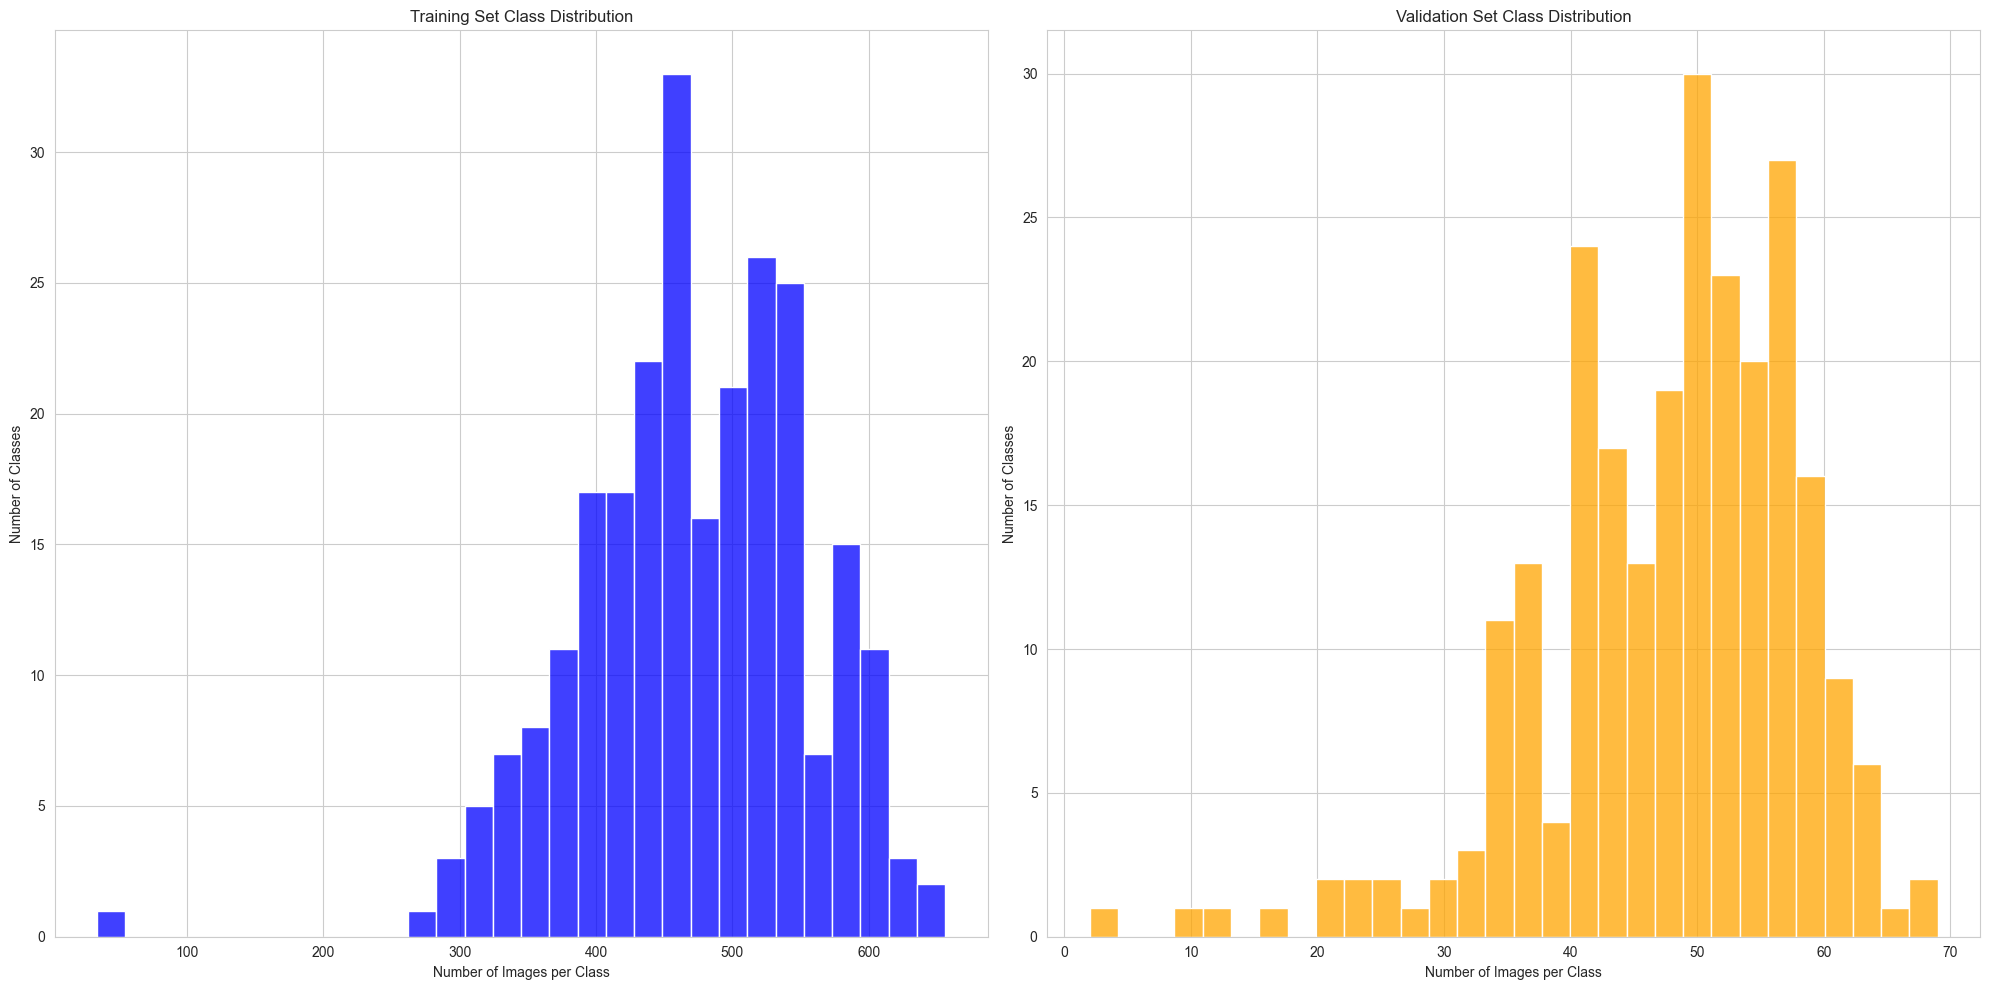

In [26]:
# Data files

from matplotlib import axes


train_cv = Path(DATA_DIR) / "train_labels.csv"
val_cv = Path(DATA_DIR) / "val_labels.csv"

print(f"Train directory: {train_cv}")
print(f"Validation directory: {val_cv}")

# Load training data
train_df = pd.read_csv(train_cv)
val_df = pd.read_csv(val_cv)

print(f"\nTrain Dataset Shape: {train_df.shape}")
print(f"\nValidation Dataset Shape: {val_df.shape}")

# Visualize class distribution in pie charts for both training and validation sets 
class_counts_train = train_df["label"].value_counts().sort_values()
class_counts_val = val_df["label"].value_counts().sort_values()


subplot_titles = ["Training Set Class Distribution", "Validation Set Class Distribution"]
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
# histograms
sns.histplot(class_counts_train, bins=30, ax=axes[0], color='blue')
sns.histplot(class_counts_val, bins=30, ax=axes[1], color='orange')
axes[0].set_title(subplot_titles[0])
axes[0].set_xlabel("Number of Images per Class")
axes[0].set_ylabel("Number of Classes")
axes[1].set_title(subplot_titles[1])
axes[1].set_xlabel("Number of Images per Class")
axes[1].set_ylabel("Number of Classes")
plt.tight_layout()
plt.show()

In [27]:
# Count the number images per class in both training and validation sets
num_images_per_class_train = train_df["label"].value_counts()
num_images_per_class_val = val_df["label"].value_counts()
# create a dataframe for the number of images per class
class_distribution_df = pd.DataFrame({
    "class": num_images_per_class_train.index,
    "train_count": num_images_per_class_train.values,
    "val_count": num_images_per_class_val.values
})
# sort the dataframe by the number of images in the training set
class_distribution_df = class_distribution_df.sort_values(by="train_count", ascending=False)
print("\nClass distribution (sorted by training set):")
display(class_distribution_df)


Class distribution (sorted by training set):


,class,train_count,val_count
0,218,656,69
1,147,636,67
2,155,635,65
3,0,633,64
4,117,617,64
...,...,...,...
246,103,300,21
247,83,290,17
248,164,289,11
249,213,277,9


Issues found: 3
reason
low_variance(std=0.0,mean=0.0)    1
low_variance(std=4.6,mean=1.5)    1
low_variance(std=0.4,mean=0.0)    1
Name: count, dtype: int64
Image IDs with issues:
['train_059868.jpg', 'train_063018.jpg', 'train_085645.jpg']


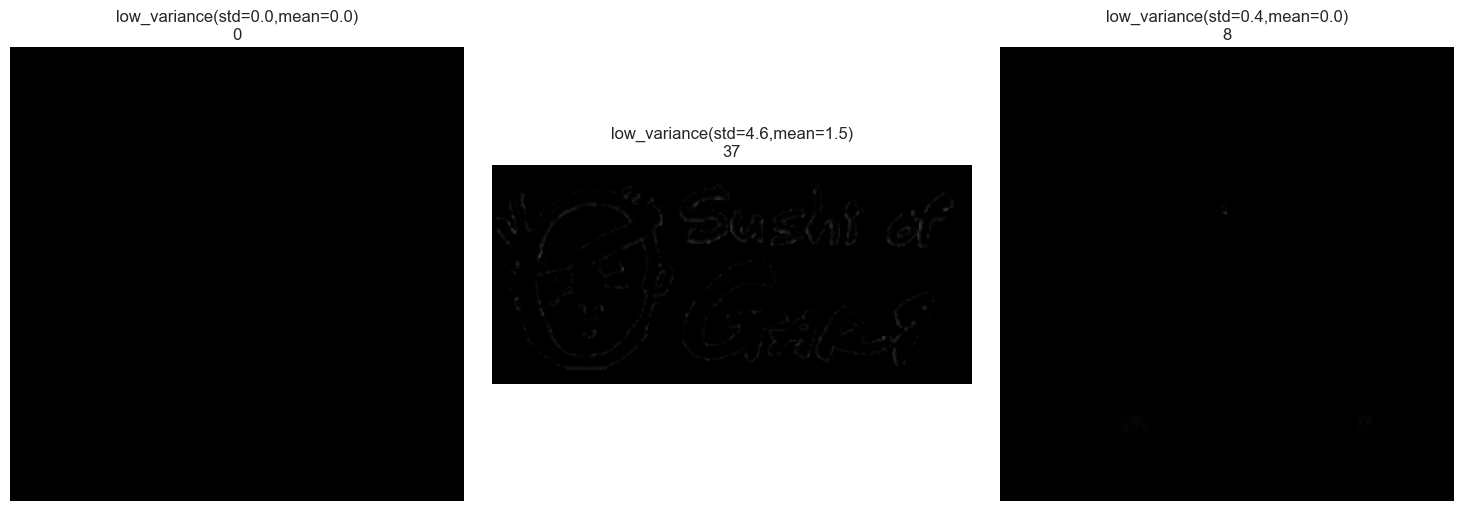

In [28]:
issues_df = audit_images(train_df, img_dir='../dataset/train_set/')
print(f"Issues found: {len(issues_df)}")
print(issues_df['reason'].value_counts())

# Remove issues from training dataframe

clean_df = train_df[~train_df['img_name'].isin(issues_df['img_name'])].reset_index(drop=True)

# Display image ids with issues
print("Image IDs with issues:")
print(issues_df['img_name'].tolist())

# Plot images with issues
if not issues_df.empty:
    fig, axes = plt.subplots(1, len(issues_df), figsize=(15, 5))
    for i, (_, row) in enumerate(issues_df.iterrows()):
        path = os.path.join('../dataset/train_set/', row['img_name'])
        try:
            img = Image.open(path).convert('RGB')
            axes[i].imshow(img)
            axes[i].set_title(f"{row['reason']}\n{row['label']}")
            axes[i].axis('off')
        except Exception as ex:
            axes[i].text(0.5, 0.5, f"Cannot open\n{row['img_name']}\n{ex}",
                         ha='center', va='center', fontsize=12)
            axes[i].set_title(f"{row['reason']}\n{row['label']}")
            axes[i].axis('off')
    plt.tight_layout()
    plt.show()


